# 05 — Analysis: RQ1 and RQ2 (P4)

Reads the P4 grid and answers:
- **RQ1:** does in-context learning degrade under covariate shift, spurious reversal and concept shift (flipped names)?
- **RQ2:** do different selection strategies win under different shift types?

Every number is a mean over tasks of the per-task mean over demonstration seeds.
- **AUROC** ranks the queries by the calibrated p1 within a cell, with no threshold. It is the confirmatory statistic.
- **BA** is calibrated balanced accuracy, which equals accuracy on the 10/10 query sets. It is shown alongside.

The confirmatory tests are the frozen contrast family (`CONTRASTS` in `src/evaluation/analysis.py`, fixed before P4): hierarchical bootstrap, one-sided, Holm-adjusted.
Everything else is descriptive.

**Data.** All P4 results come from one device, a Runpod H200 (1 October 2026, `results/v3/synthetic/h200/p4/`).
The partial run on the Mac (Apple Metal, 30 September) is used only as a cross-device check (Section 8).
`counter_prior_matched` is the exploratory variant of counter_prior that holds the shortcut's reliability fixed (`hiccups/16`).

**Why AUROC and not BA** (the user's decision; `hiccups/15`): for plain random demonstrations, calibration with the content-free query often left all 20 queries of a cell on one side of the threshold.
That pins BA at 0.5 and hides shifts. Section 5 shows how often it happens.
The notebook runs on partial results; cells that need a missing part say so.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.utils.config import load_config, resolve_path  # first src import: sets the thread and MPS settings

config = load_config()

import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.data.suites import load_suite
from src.evaluation.analysis import CONTRASTS, cell_metrics, prior_agreement, run_contrasts, summary_table

RESULTS = resolve_path(config.paths.results)
P4 = RESULTS / "h200" / "p4"          # the P4 run (Runpod H200); RESULTS / "p4" holds the Mac's partial run
grid = pd.concat([pd.read_parquet(f) for f in (P4 / "grid.parquet", P4 / "grid_cpm.parquet") if f.exists()],
                 ignore_index=True)
manifest = load_suite("eval", config)
sigma = {t["task_id"]: t["spurious_direction"] for t in manifest["tasks"]}
cells = cell_metrics(grid)
cells["spurious_direction"] = cells["task_id"].map(sigma)
print(f"{grid.unit_key.nunique()} units, {len(grid)} rows; namings {sorted(grid.naming.unique())}; "
      f"strategies {sorted(grid.strategy.unique())}")
print("median label mass:", round(float(cells['label_mass'].median()), 3))

from src.evaluation import plots

plots.use_style()
STRATEGY_ORDER = [s for s in plots.STRATEGIES if s in set(grid.strategy)]

1872 units, 112320 rows; namings ['abstract', 'aligned', 'flipped']; strategies ['counter_prior', 'counter_prior_matched', 'counter_spurious', 'feature_range', 'label_diversity', 'random', 'rule_diversity', 'similarity', 'zero_shot']
median label mass: 1.0


## 1. RQ1: does ICL degrade under shift?

Plain random demonstrations and zero-shot, by environment and naming.
The ID-minus-OOD gap of a query-agnostic strategy compares queries answered with the same prompt.

In [2]:
gold = cells[cells.label_mode == "gold"]
for value in ("ba", "auroc"):
    t = summary_table(gold[gold.strategy.isin(["zero_shot", "random", "label_diversity"])], value)
    print(value.upper()); display(t.round(3))

BA


naming           abstract                            aligned         \
env             covariate     id spurious_reversal covariate     id   
strategy                                                              
label_diversity     0.551  0.540             0.507     0.572  0.599   
random              0.541  0.549             0.499     0.567  0.587   
zero_shot           0.535  0.496             0.477     0.538  0.535   

naming                              flipped                           
env             spurious_reversal covariate     id spurious_reversal  
strategy                                                              
label_diversity             0.564     0.500  0.491             0.475  
random                      0.544     0.508  0.503             0.485  
zero_shot                   0.540     0.477  0.450             0.458

AUROC


naming           abstract                            aligned         \
env             covariate     id spurious_reversal covariate     id   
strategy                                                              
label_diversity     0.652  0.593             0.520     0.669  0.695   
random              0.579  0.603             0.488     0.652  0.688   
zero_shot           0.533  0.493             0.491     0.583  0.585   

naming                              flipped                           
env             spurious_reversal covariate     id spurious_reversal  
strategy                                                              
label_diversity             0.642     0.493  0.505             0.432  
random                      0.611     0.484  0.484             0.428  
zero_shot                   0.600     0.490  0.433             0.439

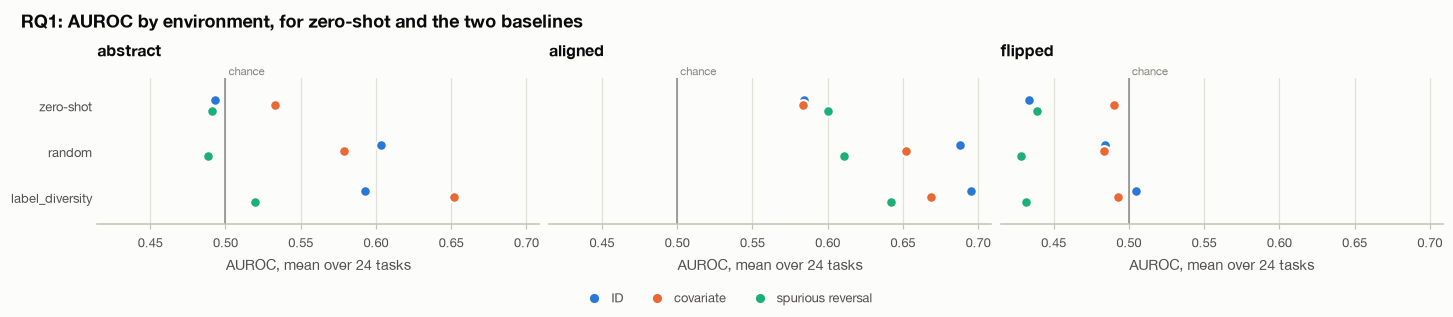

In [3]:
m = (gold[gold.strategy.isin(["zero_shot", "random", "label_diversity"])]
       .groupby(["naming", "strategy", "env", "task_id"])["auroc"].mean()
       .groupby(["naming", "strategy", "env"]).mean().reset_index())
fig = plots.facet_dots(m, facet="naming", y="strategy", x="auroc", hue="env", facet_order=plots.NAMINGS,
                       y_order=["zero_shot", "random", "label_diversity"], hue_order=plots.ENVS,
                       ref=0.5, ref_label="chance", xlabel="AUROC, mean over 24 tasks",
                       title="RQ1: AUROC by environment, for zero-shot and the two baselines")
plt.show()

**Reading the chart.** Each dot is a mean AUROC over the 24 tasks, coloured by environment; the panels are the namings, and the grey line is chance (0.5).
- **Aligned names** put every dot well right of chance. **Flipped names** pull everything to or below chance: that's the concept shift, C1c.
- **Abstract names:** spurious-reversal queries (aqua) sit left of ID queries (blue) for both baselines. The shortcut helps on ID queries and hurts under reversal (C1b).
- **Covariate queries** (orange) are not consistently below ID. That is C1a's null, explained in section 10.

## 2. RQ2: which strategy wins where?

Each strategy's BA minus label_diversity (random, balanced) on the same queries, by environment and naming.
Balanced strategies are compared with label_diversity, so label counts are held fixed.

In [4]:
t = summary_table(gold, "ba", index=("strategy",), columns=("naming", "env"))
display(t.round(3))
ref = t.loc["label_diversity"]
display((t - ref).drop(index="label_diversity").round(3))

naming                 abstract                            aligned         \
env                   covariate     id spurious_reversal covariate     id   
strategy                                                                    
counter_prior             0.553  0.556             0.494     0.576  0.591   
counter_prior_matched     0.548  0.551             0.490     0.577  0.594   
counter_spurious          0.528  0.526             0.531     0.548  0.565   
feature_range             0.526  0.532             0.495     0.553  0.565   
label_diversity           0.551  0.540             0.507     0.572  0.599   
random                    0.541  0.549             0.499     0.567  0.587   
rule_diversity            0.552  0.554             0.498     0.570  0.584   
similarity                0.571  0.562             0.479     0.583  0.579   
zero_shot                 0.535  0.496             0.477     0.538  0.535   

naming                                    flipped                           
env                   spurious_reversal covariate     id spurious_reversal  
strategy                                                                    
counter_prior                     0.571     0.494  0.508             0.484  
counter_prior_matched             0.572     0.506  0.500             0.478  
counter_spurious                  0.570     0.469  0.486             0.490  
feature_range                     0.557     0.488  0.480             0.467  
label_diversity                   0.564     0.500  0.491             0.475  
random                            0.544     0.508  0.503             0.485  
rule_diversity                    0.551     0.498  0.517             0.485  
similarity                        0.519     0.529  0.538             0.481  
zero_shot                         0.540     0.477  0.450             0.458

naming                 abstract                            aligned         \
env                   covariate     id spurious_reversal covariate     id   
strategy                                                                    
counter_prior             0.002  0.016            -0.012     0.004 -0.008   
counter_prior_matched    -0.003  0.011            -0.017     0.005 -0.005   
counter_spurious         -0.024 -0.014             0.024    -0.024 -0.033   
feature_range            -0.026 -0.008            -0.012    -0.019 -0.034   
random                   -0.010  0.010            -0.008    -0.006 -0.012   
rule_diversity            0.001  0.015            -0.009    -0.002 -0.015   
similarity                0.019  0.023            -0.028     0.011 -0.019   
zero_shot                -0.016 -0.044            -0.030    -0.035 -0.063   

naming                                    flipped                           
env                   spurious_reversal covariate     id spurious_reversal  
strategy                                                                    
counter_prior                     0.007    -0.006  0.017             0.009  
counter_prior_matched             0.008     0.006  0.009             0.003  
counter_spurious                  0.006    -0.031 -0.005             0.015  
feature_range                    -0.007    -0.013 -0.011            -0.008  
random                           -0.020     0.008  0.012             0.010  
rule_diversity                   -0.013    -0.002  0.026             0.010  
similarity                       -0.045     0.029  0.047             0.006  
zero_shot                        -0.024    -0.023 -0.041            -0.017

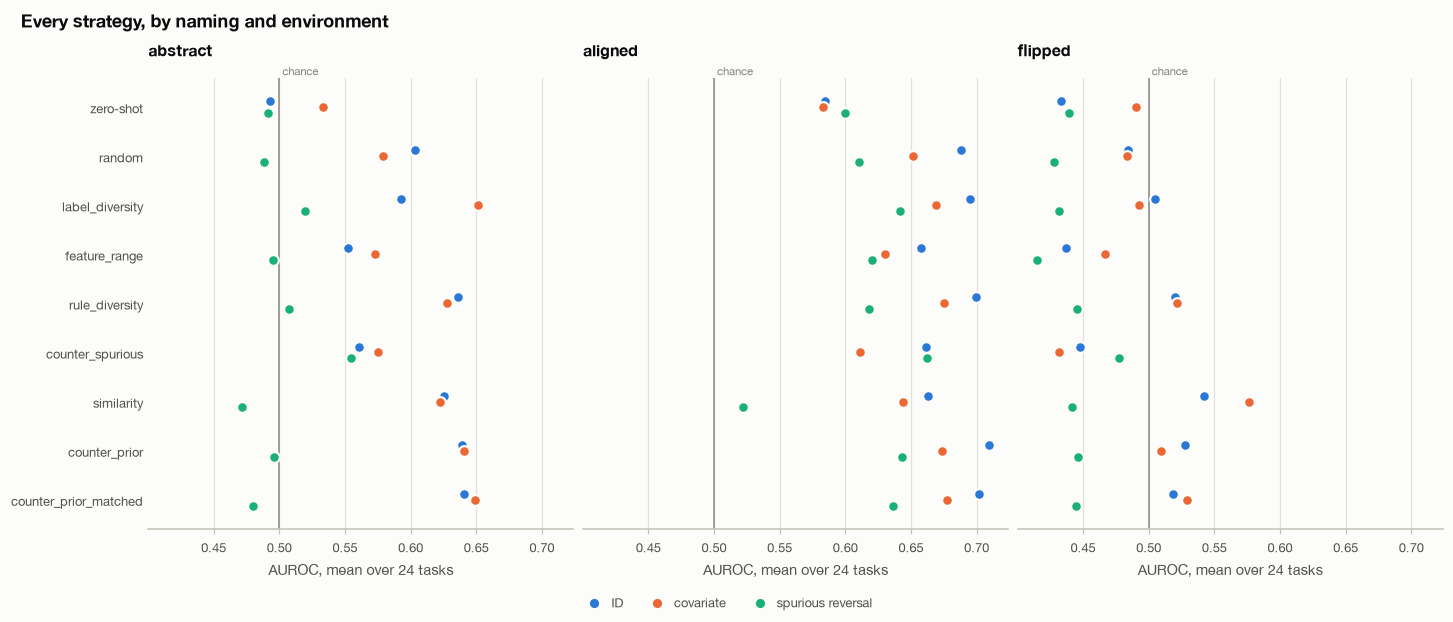

In [5]:
m_all = (gold.groupby(["naming", "strategy", "env", "task_id"])["auroc"].mean()
           .groupby(["naming", "strategy", "env"]).mean().reset_index())
fig = plots.facet_dots(m_all, facet="naming", y="strategy", x="auroc", hue="env", facet_order=plots.NAMINGS,
                       y_order=STRATEGY_ORDER, hue_order=plots.ENVS, ref=0.5, ref_label="chance",
                       xlabel="AUROC, mean over 24 tasks", title="Every strategy, by naming and environment")
plt.show()

**Reading the chart.** It's the same layout as section 1, now with every strategy. It shows AUROC, the test statistic; the table above gives calibrated balanced accuracy.
- **Strategies differ much less than namings do.** Within a panel, the strategies' ID dots spread over 0.05–0.10, excluding zero-shot.
- **Flipping the names moves every strategy.** Going from aligned to flipped shifts each strategy's ID AUROC down by 0.12–0.22.

In [6]:
t_auroc = summary_table(gold, "auroc", index=("strategy",), columns=("naming", "env"))
display((t_auroc - t_auroc.loc["label_diversity"]).drop(index="label_diversity").round(3))

naming                 abstract                            aligned         \
env                   covariate     id spurious_reversal covariate     id   
strategy                                                                    
counter_prior            -0.011  0.046            -0.023     0.005  0.014   
counter_prior_matched    -0.003  0.048            -0.039     0.008  0.007   
counter_spurious         -0.077 -0.032             0.035    -0.057 -0.034   
feature_range            -0.078 -0.041            -0.024    -0.039 -0.038   
random                   -0.073  0.010            -0.032    -0.017 -0.007   
rule_diversity           -0.024  0.043            -0.012     0.006  0.004   
similarity               -0.029  0.032            -0.048    -0.025 -0.032   
zero_shot                -0.119 -0.100            -0.028    -0.085 -0.111   

naming                                    flipped                           
env                   spurious_reversal covariate     id spurious_reversal  
strategy                                                                    
counter_prior                     0.001     0.016  0.023             0.015  
counter_prior_matched            -0.006     0.037  0.014             0.013  
counter_spurious                  0.021    -0.061 -0.057             0.046  
feature_range                    -0.022    -0.026 -0.068            -0.017  
random                           -0.031    -0.009 -0.021            -0.003  
rule_diversity                   -0.024     0.029  0.015             0.014  
similarity                       -0.120     0.084  0.038             0.010  
zero_shot                        -0.042    -0.003 -0.072             0.008

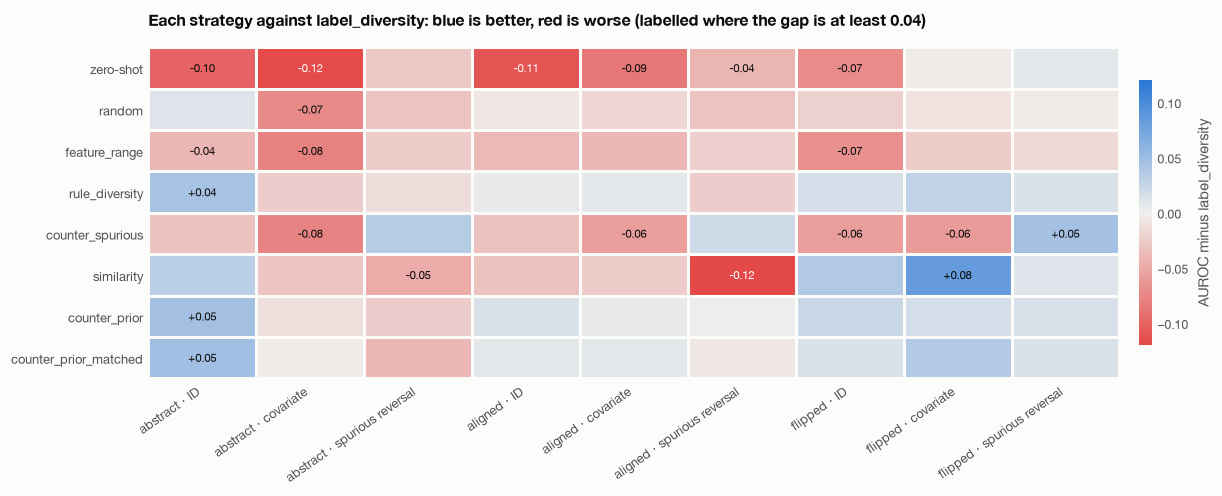

In [7]:
diff = (t_auroc - t_auroc.loc["label_diversity"]).drop(index="label_diversity")
diff = diff.loc[[s for s in STRATEGY_ORDER if s in diff.index], [(n, e) for n in plots.NAMINGS for e in plots.ENVS]]
fig, ax = plt.subplots(figsize=(11, 4.4), layout="constrained")
plots.diverging_heatmap(ax, diff, vmax=0.12, annotate_above=0.04, cbar_label="AUROC minus label_diversity")
ax.set_title("Each strategy against label_diversity: blue is better, red is worse (labelled where the gap is at least 0.04)")
plt.show()

**Reading the chart.** Each cell is a strategy's mean AUROC minus label_diversity's, for one naming and environment.
- **No strategy is blue everywhere.**
- **counter_spurious is the only strategy better than label_diversity under spurious reversal in all three namings** (+0.02 to +0.05), and it is worse on ID and covariate queries. That trade-off is what C2e tests.
- **Zero-shot is red in most cells:** demonstrations help.

## 3. The spurious direction: prior-aligned and prior-opposed tasks

Qwen's numeric prior ("bigger values mean 1") backs f8's shortcut in tasks with σ_t = +1 and opposes it where σ_t = −1 (P2, `hiccups/09`).
Spurious reversal is therefore reported for each half separately, as the plan requires.

In [8]:
sr = gold[gold.env.isin(["id", "spurious_reversal"])]
per = (sr.groupby(["strategy", "naming", "spurious_direction", "env", "task_id"])[["ba", "auroc"]].mean()
         .groupby(["strategy", "naming", "spurious_direction", "env"]).mean().unstack("env"))
for value in ("ba", "auroc"):
    per[(value, "gap")] = per[(value, "id")] - per[(value, "spurious_reversal")]
t = per.sort_index(axis=1)
display(t.round(3))

auroc         \
env                                                  gap     id   
strategy              naming   spurious_direction                 
counter_prior         abstract -1                  0.128  0.640   
                                1                  0.158  0.638   
                      aligned  -1                  0.006  0.706   
                                1                  0.127  0.713   
                      flipped  -1                 -0.011  0.483   
                                1                  0.174  0.573   
counter_prior_matched abstract -1                  0.163  0.644   
                                1                  0.158  0.638   
                      aligned  -1                  0.023  0.700   
                                1                  0.108  0.704   
                      flipped  -1                 -0.005  0.482   
                                1                  0.152  0.554   
counter_spurious      abstract -1                 -0.028  0.516   
                                1                  0.040  0.605   
                      aligned  -1                 -0.063  0.643   
                                1                  0.062  0.681   
                      flipped  -1                 -0.101  0.387   
                                1                  0.041  0.507   
feature_range         abstract -1                  0.006  0.514   
                                1                  0.109  0.591   
                      aligned  -1                 -0.040  0.625   
                                1                  0.115  0.690   
                      flipped  -1                 -0.063  0.392   
                                1                  0.107  0.482   
label_diversity       abstract -1                 -0.011  0.548   
                                1                  0.158  0.638   
                      aligned  -1                 -0.020  0.672   
                                1                  0.126  0.719   
                      flipped  -1                 -0.036  0.454   
                                1                  0.182  0.555   
random                abstract -1                  0.016  0.532   
                                1                  0.214  0.675   
                      aligned  -1                 -0.001  0.660   
                                1                  0.156  0.715   
                      flipped  -1                 -0.035  0.438   
                                1                  0.147  0.531   
rule_diversity        abstract -1                  0.071  0.591   
                                1                  0.186  0.682   
                      aligned  -1                 -0.010  0.661   
                                1                  0.173  0.738   
                      flipped  -1                 -0.049  0.463   
                                1                  0.197  0.577   
similarity            abstract -1                  0.145  0.629   
                                1                  0.163  0.622   
                      aligned  -1                  0.096  0.624   
                                1                  0.187  0.702   
                      flipped  -1                  0.082  0.562   
                                1                  0.120  0.523   
zero_shot             abstract -1                 -0.122  0.391   
                                1                  0.125  0.595   
                      aligned  -1                 -0.151  0.472   
                                1                  0.120  0.698   
                      flipped  -1                 -0.085  0.365   
                                1                  0.073  0.502   

                                                                        ba  \
env                                               spurious_reversal    gap   
strategy              naming   spurious_direction                          

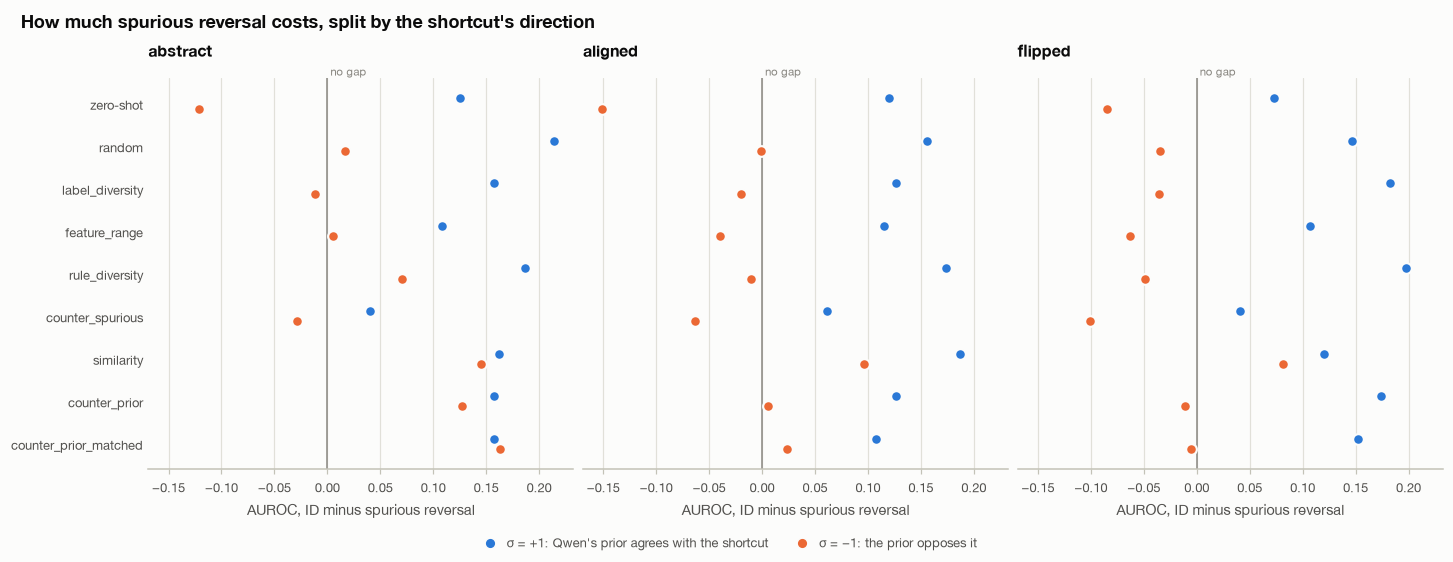

In [9]:
gap = t[("auroc", "gap")].rename("gap").reset_index()
directions = {1: "σ = +1: Qwen's prior agrees with the shortcut", -1: "σ = −1: the prior opposes it"}
gap["direction"] = gap["spurious_direction"].map(directions)
fig = plots.facet_dots(gap, facet="naming", y="strategy", x="gap", hue="direction", facet_order=plots.NAMINGS,
                       y_order=STRATEGY_ORDER, hue_order=list(directions.values()), ref=0, ref_label="no gap",
                       xlabel="AUROC, ID minus spurious reversal",
                       title="How much spurious reversal costs, split by the shortcut's direction")
plt.show()

**Reading the chart.** Each dot is the ID − spurious-reversal AUROC gap. Blue is the 12 tasks where a bigger shortcut value means label 1 (σ = +1), which agrees with Qwen's "bigger → 1" habit; orange is the other 12 (σ = −1).
- **σ = +1 tasks:** spurious reversal costs every strategy 0.04–0.21.
- **σ = −1 tasks:** most gaps are near 0 or negative. The exceptions are similarity in every naming, and both counter_prior versions under abstract names.
- **Zero-shot shows the same split with no demonstrations at all:** +0.07 to +0.13 against −0.09 to −0.15. So much of the reversal cost comes from Qwen's prior reading the shortcut in the query, not from what the demonstrations teach. Notebook 3.1 tests this directly.

## 4. Random-label control and prior agreement

- **Random-label control:** label_diversity with shuffled labels keeps the demonstrations' rows and label counts but breaks the input–label mapping. Gold minus shuffled is what the model takes from the mapping, under each naming.
- **Prior agreement:** the share of predictions equal to the model's zero-shot prediction under the same naming. High agreement means the demonstrations barely moved it.

In [10]:
ld = cells[cells.strategy == "label_diversity"]
if (ld.label_mode == "shuffled").any():
    t = (ld.groupby(["label_mode", "naming", "env", "task_id"])[["ba", "auroc"]].mean()
           .groupby(["label_mode", "naming", "env"]).mean().unstack("label_mode"))
    display(t.round(3))
else:
    print("the random-label control has not run yet")
pa = prior_agreement(grid)
display(pa[pa.label_mode == "gold"].groupby(["strategy", "naming"])["agree_raw"].mean().unstack("naming").round(3))

ba           auroc         
label_mode                   gold shuffled   gold shuffled
naming   env                                              
abstract covariate          0.551    0.515  0.652    0.558
         id                 0.540    0.503  0.593    0.529
         spurious_reversal  0.507    0.501  0.520    0.543
aligned  covariate          0.572    0.551  0.669    0.607
         id                 0.599    0.544  0.695    0.582
         spurious_reversal  0.564    0.560  0.642    0.632
flipped  covariate          0.500    0.482  0.493    0.439
         id                 0.491    0.458  0.505    0.407
         spurious_reversal  0.475    0.462  0.432    0.428

naming,abstract,aligned,flipped
strategy,,,
counter_prior,0.510,0.601,0.549
counter_prior_matched,0.501,0.599,0.549
counter_spurious,0.519,0.613,0.562
feature_range,0.529,0.636,0.582
label_diversity,0.535,0.594,0.576
random,0.537,0.608,0.584
rule_diversity,0.540,0.625,0.584
similarity,0.526,0.581,0.549


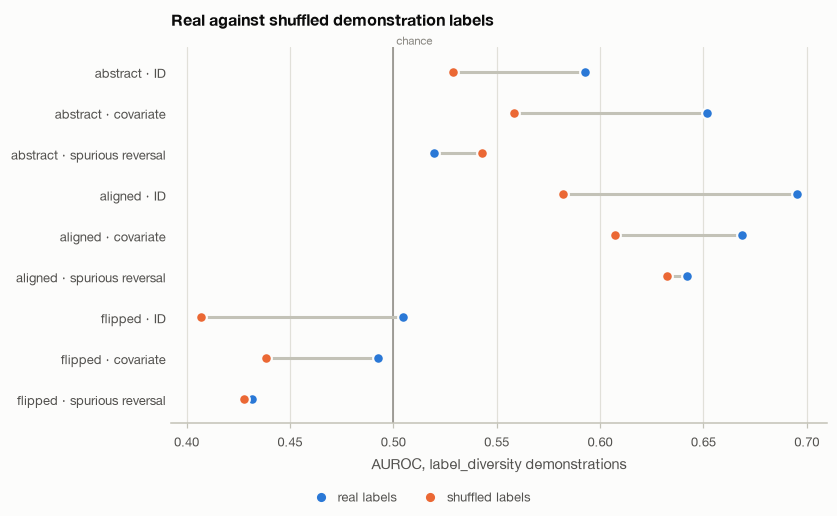

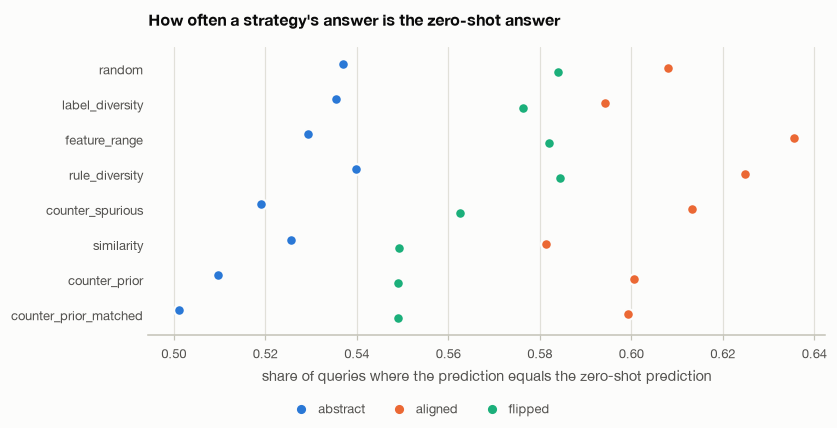

In [11]:
lc = (ld.groupby(["label_mode", "naming", "env", "task_id"])["auroc"].mean()
        .groupby(["label_mode", "naming", "env"]).mean().reset_index())
lc["row"] = lc["naming"] + " · " + lc["env"].map(plots.label)
order = [f"{n} · {plots.label(e)}" for n in plots.NAMINGS for e in plots.ENVS]
fig, ax = plt.subplots(figsize=(7.5, 4.6), layout="constrained")
plots.dots(ax, lc, y="row", x="auroc", hue="label_mode", y_order=order, hue_order=["gold", "shuffled"],
           connect=True, ref=0.5, ref_label="chance", xlabel="AUROC, label_diversity demonstrations")
plots.legend_below(fig, ["real labels", "shuffled labels"], plots.SERIES[:2])
ax.set_title("Real against shuffled demonstration labels")
plt.show()

pa_m = pa[pa.label_mode == "gold"].groupby(["strategy", "naming"])["agree_raw"].mean().reset_index()
fig, ax = plt.subplots(figsize=(7.5, 3.8), layout="constrained")
plots.dots(ax, pa_m, y="strategy", x="agree_raw", hue="naming", y_order=[s for s in STRATEGY_ORDER if s != "zero_shot"],
           hue_order=plots.NAMINGS, xlabel="share of queries where the prediction equals the zero-shot prediction")
plots.legend_below(fig, plots.NAMINGS, plots.SERIES)
ax.set_title("How often a strategy's answer is the zero-shot answer")
plt.show()

**Reading the charts.**
- **First chart:** each row joins a real-label dot to a shuffled-label dot. The distance between them is what Qwen takes from the input–label mapping.
  - Real labels lead in every row except abstract spurious reversal (0.520 against 0.543).
  - Under spurious reversal the difference is small in every naming (−0.02 to +0.01).
- **Second chart:** with aligned names, predictions agree with the zero-shot answer most often (0.58–0.64, against 0.50–0.54 abstract and 0.55–0.58 flipped). That fits the names and the demonstrations pointing the same way.

## 5. Why calibrated BA is not the test statistic

The share of cells in which calibration puts every query on one side of the threshold, by strategy and naming, and how far the content-free margin sits from the cell's median query margin.

In [12]:
from src.evaluation.analysis import prepare

g = prepare(grid[grid.strategy != "zero_shot"])
g["margin_cf"] = g["logprob_1_cf"] - g["logprob_0_cf"]
per_cell = (g.groupby(["strategy", "naming", "task_id", "seed", "env"])
              .apply(lambda c: pd.Series({"one_class": c["pred"].nunique() == 1,
                                          "cf_minus_median": c["margin_cf"].iloc[0] - c["margin"].median()}),
                     include_groups=False).reset_index())
display(per_cell.groupby(["strategy", "naming"])[["one_class", "cf_minus_median"]].mean().unstack("naming").round(3))

one_class                 cf_minus_median          \
naming                 abstract aligned flipped        abstract aligned   
strategy                                                                  
counter_prior             0.296   0.162   0.273          -1.460  -2.000   
counter_prior_matched     0.296   0.148   0.241          -0.943  -1.971   
counter_spurious          0.218   0.120   0.273          -1.279  -1.466   
feature_range             0.144   0.171   0.227          -1.477  -1.814   
label_diversity           0.088   0.023   0.102          -2.385  -2.499   
random                    0.306   0.236   0.366          -1.762  -2.727   
rule_diversity            0.213   0.148   0.269          -1.822  -2.563   
similarity                0.028   0.028   0.083          -2.974  -3.485   

                               
naming                flipped  
strategy                       
counter_prior          -1.133  
counter_prior_matched  -0.933  
counter_spurious       -0.665  
feature_range          -1.607  
label_diversity        -2.398  
random                 -2.561  
rule_diversity         -1.923  
similarity             -3.106

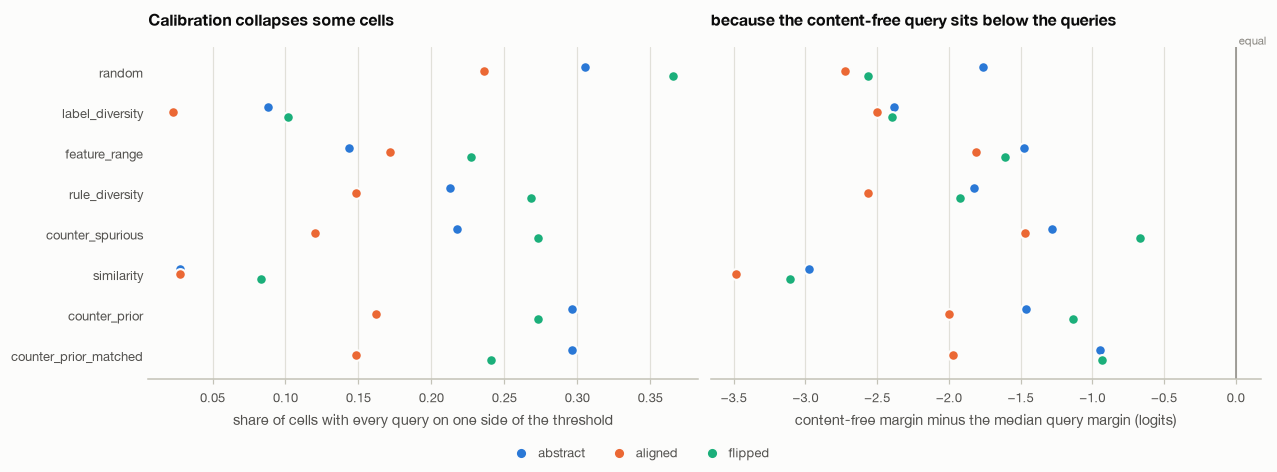

In [13]:
pc = per_cell.groupby(["strategy", "naming"])[["one_class", "cf_minus_median"]].mean().reset_index()
rows = [s for s in STRATEGY_ORDER if s != "zero_shot"]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True, layout="constrained")
plots.dots(axes[0], pc, y="strategy", x="one_class", hue="naming", y_order=rows, hue_order=plots.NAMINGS,
           xlabel="share of cells with every query on one side of the threshold")
axes[0].set_title("Calibration collapses some cells")
plots.dots(axes[1], pc, y="strategy", x="cf_minus_median", hue="naming", y_order=rows, hue_order=plots.NAMINGS,
           ref=0, ref_label="equal",
           xlabel="content-free margin minus the median query margin (logits)")
axes[1].set_title("because the content-free query sits below the queries")
plots.legend_below(fig, plots.NAMINGS, plots.SERIES)
plt.show()

**Reading the charts.**
- **Left:** how often contextual calibration put all 20 queries of a cell on one side of the threshold. random collapses most often (24–37% of cells), similarity least (3–8%).
- **Right:** why. The content-free query's margin sits 0.7–3.5 logits below the typical query's. Subtracting it pushes most queries to "1", which pins balanced accuracy at 0.5 (`hiccups/15`). AUROC is unaffected, because calibration never reorders a cell's queries.

## 6. What the demonstration sets contain

Per strategy and naming, split by the task's spurious direction σ_t, the demonstration sets hold:
- the share of rows whose spurious feature agrees with their label (the shortcut's apparent reliability; the pool's rate is the task's strength, 0.80–0.90);
- the share labelled 1;
- the share of label-noise rows.

counter_prior picks rows on which the model's zero-shot answer is wrong.
With abstract names that answer mostly follows "bigger values mean 1", so where σ_t = −1 the wrong answers fall mainly on shortcut-agreeing rows.
This table shows whether counter_prior therefore reinforces the shortcut.

In [14]:
from src.data.suites import suite_dir
from src.data.synthetic_bridge import load_task_frame, pool_of

pools = {t: pool_of(load_task_frame(suite_dir("eval", config), t)) for t in grid.task_id.unique()}
units = grid[grid.label_mode == "gold"].drop_duplicates("unit_key")
units = units[units.strategy.isin(["random", "label_diversity", "feature_range", "rule_diversity",
                                   "counter_spurious", "counter_prior"])]
rows = []
for _, u in units.iterrows():
    d = pools[u.task_id].loc[list(u.demo_ids)]
    rows.append({"strategy": u.strategy, "naming": u.naming, "sigma": sigma[u.task_id],
                 "f8_agrees": d["agree_obs"].mean(), "label_1": d["label"].mean(),
                 "label_noise": (d["label"] != d["y_clean"]).mean()})
comp = pd.DataFrame(rows)
display(comp.groupby(["strategy", "naming", "sigma"])[["f8_agrees", "label_1", "label_noise"]].mean().unstack("sigma").round(3))

f8_agrees        label_1       label_noise       
sigma                            -1      1      -1     1          -1      1
strategy         naming                                                    
counter_prior    abstract     0.875  0.837   0.500  0.50       0.003  0.017
                 aligned      0.872  0.823   0.500  0.50       0.010  0.014
                 flipped      0.878  0.847   0.500  0.50       0.003  0.014
counter_spurious abstract     0.500  0.500   0.500  0.50       0.000  0.000
                 aligned      0.500  0.500   0.500  0.50       0.000  0.000
                 flipped      0.500  0.500   0.500  0.50       0.000  0.000
feature_range    abstract     0.670  0.653   0.500  0.50       0.097  0.062
                 aligned      0.670  0.653   0.500  0.50       0.097  0.062
                 flipped      0.670  0.653   0.500  0.50       0.097  0.062
label_diversity  abstract     0.837  0.837   0.500  0.50       0.021  0.017
                 aligned      0.837  0.837   0.500  0.50       0.021  0.017
                 flipped      0.837  0.837   0.500  0.50       0.021  0.017
random           abstract     0.844  0.844   0.517  0.49       0.031  0.028
                 aligned      0.844  0.844   0.517  0.49       0.031  0.028
                 flipped      0.844  0.844   0.517  0.49       0.031  0.028
rule_diversity   abstract     0.882  0.851   0.500  0.50       0.000  0.000
                 aligned      0.882  0.851   0.500  0.50       0.000  0.000
                 flipped      0.882  0.851   0.500  0.50       0.000  0.000

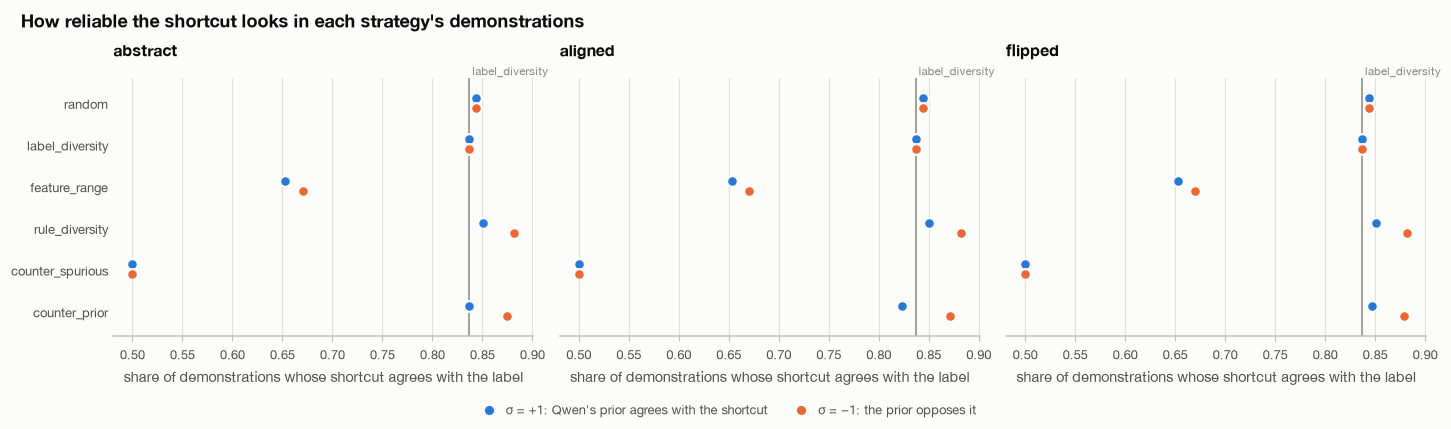

In [15]:
cm = comp.groupby(["strategy", "naming", "sigma"])["f8_agrees"].mean().reset_index()
cm["direction"] = cm["sigma"].map(directions)        # the same labels and colours as the gap chart in section 3
fig = plots.facet_dots(cm, facet="naming", y="strategy", x="f8_agrees", hue="direction", facet_order=plots.NAMINGS,
                       y_order=[s for s in STRATEGY_ORDER if s in set(cm.strategy)], hue_order=list(directions.values()),
                       ref=float(comp.loc[comp.strategy == "label_diversity", "f8_agrees"].mean()),
                       ref_label="label_diversity",
                       xlabel="share of demonstrations whose shortcut agrees with the label",
                       title="How reliable the shortcut looks in each strategy's demonstrations")
plt.show()

**Reading the chart.** It shows how often the shortcut is right inside the 8 demonstrations, split by the task's spurious direction.
- **counter_spurious** sits at 0.5 by design.
- **feature_range** sits at about 0.66, because it spreads its rows over the shortcut's values (`hiccups/19`).
- **counter_prior** sits right of label_diversity where σ = −1 (0.87–0.88 against 0.84). It makes the shortcut look *more* reliable there (`hiccups/16`).

## 7. The contrast family (confirmatory)

Ten one-sided contrasts, Holm-adjusted together.
The RQ3 contrasts (C3a, C3b) come from `06_faithfulness_and_probes`; here they enter the family once `p4/rq3.parquet` exists.
A contrast whose conditions have not run yet is skipped, and the Holm adjustment then covers only the contrasts present, so it is final only when all ten are.

In [16]:
from src.evaluation.analysis import true_importance_by_column

rq3_path = P4 / "rq3.parquet"
rq3 = pd.read_parquet(rq3_path) if rq3_path.exists() else None
available = []
for c in CONTRASTS:
    if c["kind"].startswith("rq3"):
        ok = rq3 is not None and {c["naming_a"], c["naming_b"]} <= set(rq3.naming)
    else:
        need_n = {c.get("naming"), c.get("naming_a"), c.get("naming_b")} - {None}
        need_s = {c.get("strategy"), c.get("a"), c.get("b")} - {None}
        ok = need_n <= set(grid.naming) and need_s <= set(grid.strategy)
    if ok:
        available.append(c)
res = run_contrasts(grid, rq3, true_importance_by_column(manifest), n_bootstrap=2000, contrasts=available)
print(f"{len(available)} of {len(CONTRASTS)} contrasts available")
with pd.option_context("display.max_colwidth", 80):
    display(res.round(4))
res.to_csv(P4 / "contrasts.csv", index=False)

10 of 10 contrasts available


,id,rq,label,statistic,estimate,ci_low,ci_high,p_one_sided,tasks_in_direction,n_tasks,sign_test_p,ba_estimate,ba_ci,p_holm,significant
0,C1a,RQ1,"ID minus covariate, random demonstrations, abstract names",auroc,0.0243,-0.0444,0.0932,0.2384,15,24,0.1537,0.0083,"[-0.028472222222222232, 0.04722222222222223]",0.9535,False
1,C1b,RQ1,"ID minus spurious reversal, random demonstrations, abstract names",auroc,0.1153,0.0169,0.2175,0.0090,16,24,0.0758,0.0500,"[0.009027777777777796, 0.09444444444444444]",0.0630,False
2,C1c,RQ1,"aligned minus flipped names (concept shift), random demonstrations, ID",auroc,0.2036,0.1305,0.2801,0.0005,22,24,0.0000,0.0840,"[0.05000000000000001, 0.1173611111111111]",0.0050,True
3,C2a,RQ2,counter_spurious minus label_diversity under spurious reversal,auroc,0.0349,-0.0186,0.0856,0.0980,16,24,0.0758,0.0236,"[-0.014583333333333328, 0.06111111111111109]",0.5877,False
4,C2b,RQ2,similarity (feature kNN) minus label_diversity under covariate shift,auroc,-0.0294,-0.1103,0.0476,0.7831,11,24,0.7294,0.0194,"[-0.03541666666666666, 0.07085069444444436]",1.0000,False
5,C2c,RQ2,feature_range minus label_diversity under covariate shift,auroc,-0.0785,-0.1414,-0.0181,0.9940,6,24,0.9967,-0.0257,"[-0.06874999999999999, 0.015989583333333248]",1.0000,False
6,C2d,RQ2,"counter_prior minus label_diversity under concept shift (flipped names, ID)",auroc,0.0231,-0.0149,0.0638,0.1394,7,24,0.6964,0.0174,"[-0.00833333333333334, 0.045138888888888874]",0.6972,False
7,C2e,RQ2,(counter_spurious minus label_diversity) under spurious reversal minus the s...,auroc,0.1114,0.0329,0.1958,0.0030,17,24,0.0320,0.0472,"[-0.004861111111111108, 0.10348958333333325]",0.0240,True
8,C3a,RQ3,"demo-following index, abstract minus flipped names",dfi,0.1229,0.0792,0.1748,0.0005,23,24,0.0000,NaN,None,0.0050,True
9,C3b,RQ3,"rho(pi_true, pi_behav), abstract minus flipped names",rho,0.0261,-0.1414,0.1737,0.3948,13,24,0.3388,NaN,None,1.0000,False


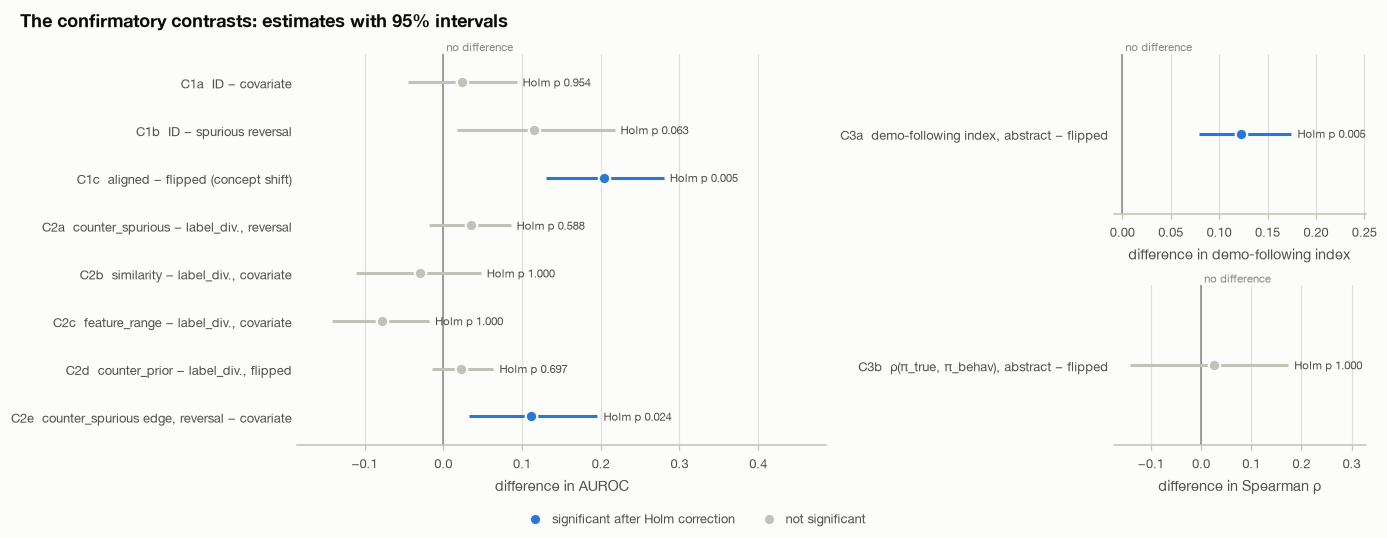

In [17]:
short = {"C1a": "C1a  ID − covariate", "C1b": "C1b  ID − spurious reversal",
         "C1c": "C1c  aligned − flipped (concept shift)",
         "C2a": "C2a  counter_spurious − label_div., reversal", "C2b": "C2b  similarity − label_div., covariate",
         "C2c": "C2c  feature_range − label_div., covariate", "C2d": "C2d  counter_prior − label_div., flipped",
         "C2e": "C2e  counter_spurious edge, reversal − covariate",
         "C3a": "C3a  demo-following index, abstract − flipped", "C3b": "C3b  ρ(π_true, π_behav), abstract − flipped"}
r2 = res.assign(row=res["id"].map(short), note=res["p_holm"].map(lambda p: f"Holm p {p:.3f}"))
fig = plt.figure(figsize=(12.5, 4.8), layout="constrained")
gs = fig.add_gridspec(2, 2, width_ratios=[2.1, 1])
ax1, ax2, ax3 = fig.add_subplot(gs[:, 0]), fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])
plots.forest(ax1, r2[r2.statistic == "auroc"], "row", "estimate", "ci_low", "ci_high", emphasis="significant",
             note="note", xlabel="difference in AUROC")
plots.forest(ax2, r2[r2.id == "C3a"], "row", "estimate", "ci_low", "ci_high", emphasis="significant",
             note="note", xlabel="difference in demo-following index")
plots.forest(ax3, r2[r2.id == "C3b"], "row", "estimate", "ci_low", "ci_high", emphasis="significant",
             note="note", xlabel="difference in Spearman ρ")
plots.legend_below(fig, ["significant after Holm correction", "not significant"], [plots.BLUE, plots.CONTEXT])
fig.suptitle("The confirmatory contrasts: estimates with 95% intervals", x=0.01, ha="left")
plt.show()

**Reading the chart.** Each row is one pre-registered contrast, with its estimate and 95% interval. Blue rows survive Holm correction across the family of ten.
- **The three that survive:** concept shift (C1c, +0.20), counter_spurious's advantage under reversal over covariate shift (C2e, +0.11), and the demo-following index (C3a, +0.12).
- **C1b's interval clears 0,** but its Holm-adjusted p is 0.063.
- **C2c's interval is the only one wholly below 0:** feature_range loses to label_diversity under covariate shift (`hiccups/19`).

## 8. Cross-device check: the H200 against the Mac

Every unit the Mac also ran (abstract names in full, part of the named grid) has the same prompt and demonstration rows on both devices.
Only the kernels differ (Apple Metal against CUDA, both bf16).

In [18]:
from src.evaluation.metrics import auroc

mac = pd.read_parquet(RESULTS / "p4" / "grid.parquet")
j = grid.merge(mac, on=["unit_key", "env", "query_id"], suffixes=("_h", "_m"))
mh, mm = j.logprob_1_h - j.logprob_0_h, j.logprob_1_m - j.logprob_0_m
cells = j.groupby(["unit_key", "env"]).apply(lambda c: pd.Series({
    "h200": auroc(c.label_h.astype(int), c.p1_h), "mac": auroc(c.label_m.astype(int), c.p1_m)}), include_groups=False)
print(f"{j.unit_key.nunique()} units on both devices; identical prompts: {bool((j.prompt_hash_h == j.prompt_hash_m).all())}")
print(f"margin correlation {np.corrcoef(mh, mm)[0, 1]:.4f}, median |difference| {np.median(np.abs(mh - mm)):.3f} logits")
print(f"same raw prediction {np.mean(j.prediction_h == j.prediction_m):.3f}; same calibrated prediction {np.mean(j.prediction_cal_h == j.prediction_cal_m):.3f}")
print(f"mean cell AUROC: H200 {cells.h200.mean():.4f}, Mac {cells.mac.mean():.4f}; mean |cell difference| {np.mean(np.abs(cells.h200 - cells.mac)):.4f}")

1015 units on both devices; identical prompts: True
margin correlation 0.9964, median |difference| 0.220 logits
same raw prediction 0.984; same calibrated prediction 0.900
mean cell AUROC: H200 0.5611, Mac 0.5607; mean |cell difference| 0.0172


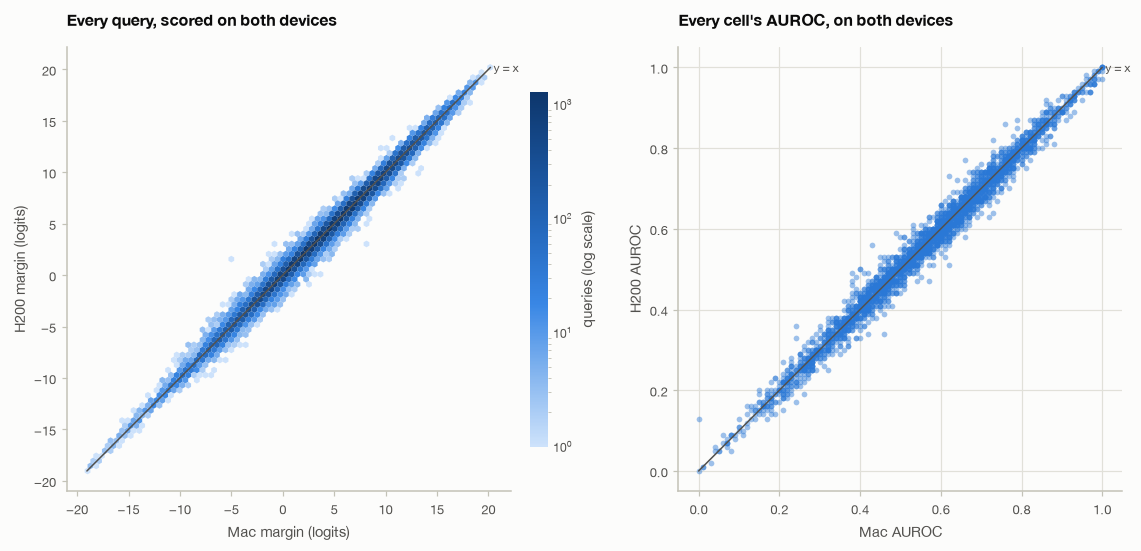

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.9), layout="constrained")
plots.density_identity(axes[0], mm, mh, xlabel="Mac margin (logits)", ylabel="H200 margin (logits)")
axes[0].set_title("Every query, scored on both devices")
plots.identity_scatter(axes[1], cells["mac"], cells["h200"], xlabel="Mac AUROC", ylabel="H200 AUROC")
axes[1].set_title("Every cell's AUROC, on both devices")
plt.show()

**Reading the charts.**
- **Left:** each query's margin on the Mac against the H200. They lie along y = x (correlation 0.996, median difference 0.22 logits).
- **Right:** each cell's AUROC on both devices. The cells scatter tightly around y = x (mean |difference| 0.017), so the device does not move the AUROC results.

## 9. Qwen2.5-7B base (reduced grid)

Abstract and flipped names; zero-shot, random, counter_spurious, counter_prior and counter_prior_matched.
It passed the P2 checks at k = 8 on the pilot (`p4/base_p2_gate.json`).

In [20]:
base = pd.concat([pd.read_parquet(f) for f in (P4 / "grid_base.parquet", P4 / "grid_base_cpm.parquet") if f.exists()],
                 ignore_index=True)
print(json.loads((P4 / "base_p2_gate.json").read_text())["gate"])
cb = cell_metrics(base)
display(summary_table(cb, "auroc", index=("strategy",), columns=("naming", "env")).round(3))

[{'model': 'qwen2.5-7b-base', 'k': 8, 'auroc_gold': 0.6238888888888889, 'auroc_shuffled': 0.5205555555555557, 'delta_auroc': 0.10333333333333335, 'ci_low': 0.02333333333333334, 'ci_high': 0.18611111111111112, 'tasks_positive': 11, 'n_tasks': 12, 'cal_ba_gold': 0.5513888888888889, 'cal_ba_shuffled': 0.5013888888888889, 'label_mass': 0.9998163094611813, 'auroc_zero_shot': 0.4675, 'label_mass_zero_shot': 0.989747882068748, 'valid': True, 'passes': True}]


naming                 abstract                            flipped         \
env                   covariate     id spurious_reversal covariate     id   
strategy                                                                    
counter_prior             0.652  0.637             0.485     0.596  0.594   
counter_prior_matched     0.667  0.655             0.499     0.627  0.607   
counter_spurious          0.564  0.550             0.560     0.471  0.491   
random                    0.628  0.625             0.504     0.550  0.560   
zero_shot                 0.503  0.516             0.470     0.525  0.456   

naming                                   
env                   spurious_reversal  
strategy                                 
counter_prior                     0.444  
counter_prior_matched             0.435  
counter_spurious                  0.534  
random                            0.461  
zero_shot                         0.542

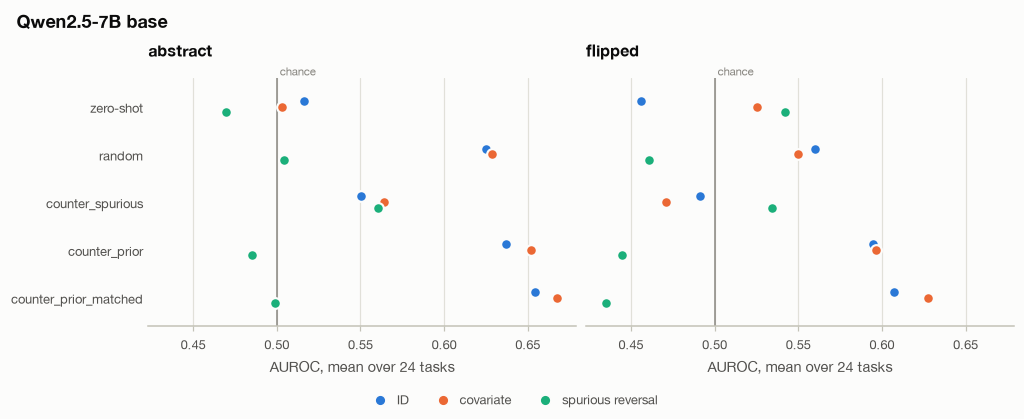

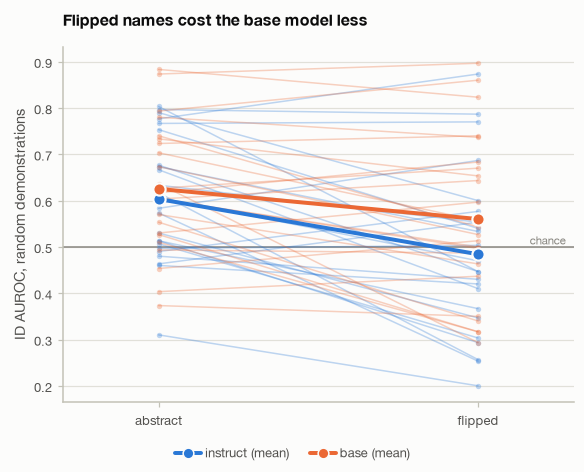

In [21]:
mb = (cb[cb.label_mode == "gold"].groupby(["naming", "strategy", "env", "task_id"])["auroc"].mean()
        .groupby(["naming", "strategy", "env"]).mean().reset_index())
fig = plots.facet_dots(mb, facet="naming", y="strategy", x="auroc", hue="env", facet_order=["abstract", "flipped"],
                       y_order=[s for s in STRATEGY_ORDER if s in set(mb.strategy)], hue_order=plots.ENVS,
                       ref=0.5, ref_label="chance", xlabel="AUROC, mean over 24 tasks", title="Qwen2.5-7B base")
plt.show()

ins = (gold[(gold.strategy == "random") & (gold.env == "id") & gold.naming.isin(["abstract", "flipped"])]
       .groupby(["task_id", "naming"])["auroc"].mean().unstack("naming"))
bas = (cb[(cb.label_mode == "gold") & (cb.strategy == "random") & (cb.env == "id")]
       .groupby(["task_id", "naming"])["auroc"].mean().unstack("naming"))
both = pd.concat({"instruct": ins, "base": bas}, names=["model"]).reset_index(level="model")
fig, ax = plt.subplots(figsize=(5.2, 4.2), layout="constrained")
h = plots.slopes(ax, both, ["abstract", "flipped"], group=both["model"], group_order=["instruct", "base"],
                 ref=0.5, ref_label="chance", ylabel="ID AUROC, random demonstrations")
plots.legend_below(fig, h)
ax.set_title("Flipped names cost the base model less")
plt.show()

**Reading the charts.**
- **First chart:** the base model's grid, in the same layout as section 2.
- **Second chart:** thin lines are single tasks, thick lines the means, for random demonstrations on ID queries. Flipping the names drops the instruct model from 0.603 to 0.484 and the base model only from 0.625 to 0.560.

## 10. Covariate shift beyond within-environment AUROC (exploratory, `hiccups/18`)

C1a found no covariate harm.
The `covariate` shift adds the same vector to every covariate query, and the shortcut stays valid under it.
So within-environment AUROC can only see a covariate effect that reorders queries.

**(1) Scores across environments.**
- `score_shift` is the mean calibrated margin on covariate queries minus on ID queries, for the same demonstration set.
- The cross-environment AUROCs rank one environment's positives against the other's negatives, so a uniform shift shows up there.

In [22]:
from src.evaluation.analysis import cross_environment_auroc, exploratory_contrasts, task_level_interval

ce = cross_environment_auroc(grid[grid.strategy != "similarity"])
cols = ["auroc_id", "auroc_covariate", "id_pos_vs_covariate_neg", "covariate_pos_vs_id_neg",
        "pooled_auroc", "score_shift", "share_1_id", "share_1_covariate"]
display(ce.groupby(["naming", "strategy"])[cols].mean().round(3))
r = ce[(ce.strategy == "random") & (ce.naming == "abstract")].set_index("task_id")
print("random, abstract: score shift", [round(x, 3) for x in task_level_interval(r["score_shift"])],
      "| ID positives vs covariate negatives", [round(x, 3) for x in task_level_interval(r["id_pos_vs_covariate_neg"])])

auroc_id  auroc_covariate  \
naming   strategy                                           
abstract counter_prior             0.639            0.641   
         counter_prior_matched     0.641            0.649   
         counter_spurious          0.561            0.575   
         feature_range             0.552            0.573   
         label_diversity           0.593            0.652   
         random                    0.603            0.579   
         rule_diversity            0.636            0.628   
         zero_shot                 0.493            0.533   
aligned  counter_prior             0.709            0.674   
         counter_prior_matched     0.702            0.677   
         counter_spurious          0.662            0.611   
         feature_range             0.658            0.630   
         label_diversity           0.695            0.669   
         random                    0.688            0.652   
         rule_diversity            0.700            0.675   
         zero_shot                 0.585            0.583   
flipped  counter_prior             0.528            0.509   
         counter_prior_matched     0.518            0.529   
         counter_spurious          0.447            0.432   
         feature_range             0.437            0.466   
         label_diversity           0.505            0.493   
         random                    0.484            0.484   
         rule_diversity            0.520            0.522   
         zero_shot                 0.433            0.490   

                                id_pos_vs_covariate_neg  \
naming   strategy                                         
abstract counter_prior                            0.517   
         counter_prior_matched                    0.537   
         counter_spurious                         0.483   
         feature_range                            0.457   
         label_diversity                          0.512   
         random                                   0.539   
         rule_diversity                           0.500   
         zero_shot                                0.542   
aligned  counter_prior                            0.630   
         counter_prior_matched                    0.603   
         counter_spurious                         0.574   
         feature_range                            0.586   
         label_diversity                          0.600   
         random                                   0.602   
         rule_diversity                           0.592   
         zero_shot                                0.575   
flipped  counter_prior                            0.469   
         counter_prior_matched                    0.478   
         counter_spurious                         0.392   
         feature_range                            0.390   
         label_diversity                          0.435   
         random                                   0.429   
         rule_diversity                           0.462   
         zero_shot                                0.450   

                                covariate_pos_vs_id_neg  pooled_auroc  \
naming   strategy                                                       
abstract counter_prior                            0.720         0.629   
         counter_prior_matched                    0.719         0.636   
         counter_spurious                         0.640         0.564   
         feature_range                            0.658         0.560   
         label_diversity                          0.688         0.611   
         random                                   0.625         0.586   
         rule_diversity                           0.744         0.627   
         zero_shot                                0.467         0.509   
aligned  counter_prior                            0.718         0.683   
         counter_prior_matched                    0.731         0.678   
         counter_spurious         

random, abstract: score shift [0.488, 0.034, 0.967] | ID positives vs covariate negatives [0.539, 0.478, 0.606]


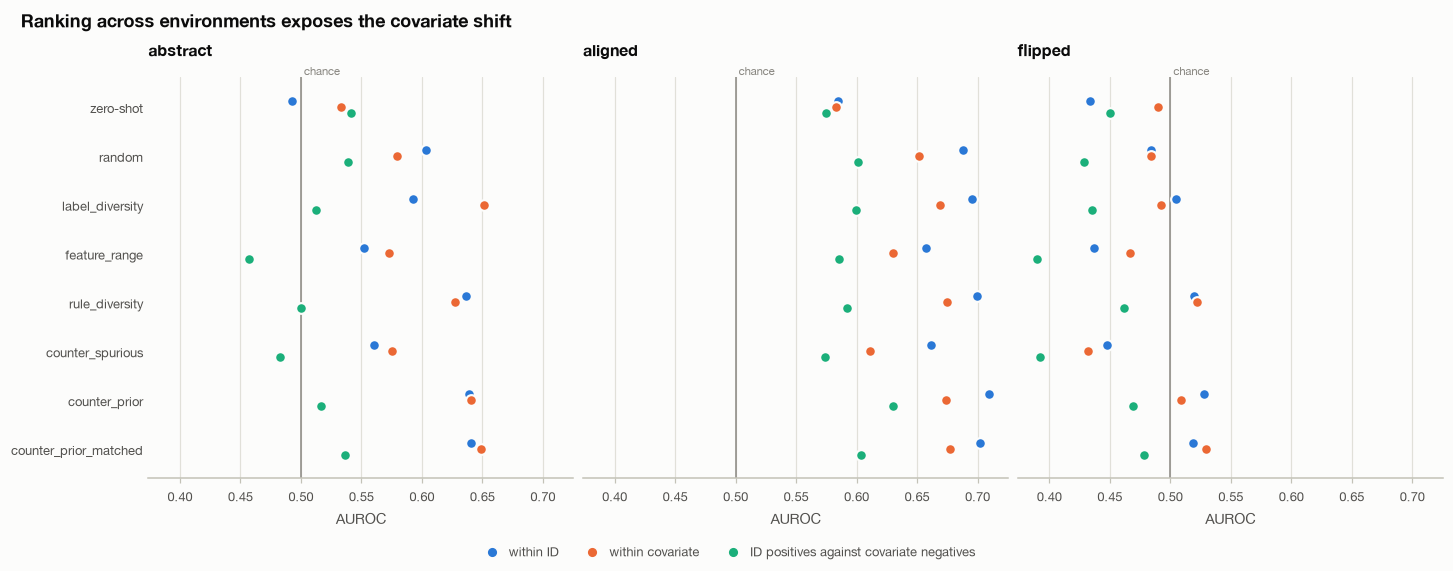

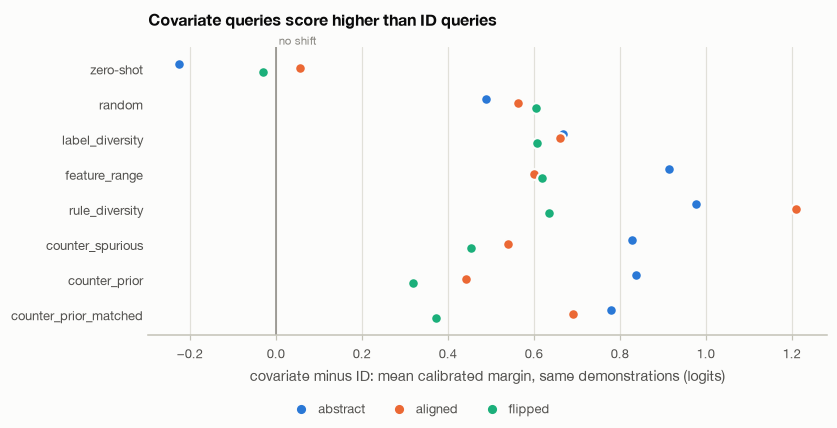

In [23]:
names = {"auroc_id": "within ID", "auroc_covariate": "within covariate",
         "id_pos_vs_covariate_neg": "ID positives against covariate negatives"}
cmp_ = ce.groupby(["naming", "strategy"])[list(names)].mean().reset_index().melt(
    id_vars=["naming", "strategy"], var_name="comparison", value_name="auroc")
cmp_["comparison"] = cmp_["comparison"].map(names)
rows = [s for s in STRATEGY_ORDER if s in set(cmp_.strategy)]
fig = plots.facet_dots(cmp_, facet="naming", y="strategy", x="auroc", hue="comparison", facet_order=plots.NAMINGS,
                       y_order=rows, hue_order=list(names.values()), ref=0.5, ref_label="chance", xlabel="AUROC",
                       title="Ranking across environments exposes the covariate shift")
plt.show()

sh = ce.groupby(["naming", "strategy"])["score_shift"].mean().reset_index()
fig, ax = plt.subplots(figsize=(7.5, 3.8), layout="constrained")
plots.dots(ax, sh, y="strategy", x="score_shift", hue="naming", y_order=rows, hue_order=plots.NAMINGS,
           ref=0, ref_label="no shift", xlabel="covariate minus ID: mean calibrated margin, same demonstrations (logits)")
plots.legend_below(fig, plots.NAMINGS, plots.SERIES)
ax.set_title("Covariate queries score higher than ID queries")
plt.show()

**Reading the charts.**
- **First chart:** within ID and within covariate queries (blue, orange), the rankings are similar. Ranking ID positives against *covariate* negatives (aqua) drops towards chance, to 0.46–0.54 under abstract names. Shifted negatives score like positives.
- **Second chart:** why. With demonstrations, covariate queries score 0.44–1.21 logits higher than ID queries, and zero-shot shows no such shift. A uniform shift like this moves every covariate query together, so within-environment AUROC (C1a) cannot see it (`hiccups/18`).

**(2) A variance shift that can reorder queries** (`covariate_scale`).
- Every covariate but f8 is stretched by its own factor in U(1.5, 3).
- The rule, the 50/50 label rate and the shortcut are unchanged.

**(3) Shortcut protection.**
- The ID, covariate and covariate_scale queries are copied with f8 replaced by pool values unrelated to the label (`*_f8neutral`).
- E3b and E3c ask whether the covariate gap grows once the shortcut can no longer help.

These query sets were scored on the H200 for every existing demonstration set (`p4/grid_probe.parquet`).

In [24]:
probe_path = P4 / "grid_probe.parquet"
if probe_path.exists():
    full = pd.concat([grid, pd.read_parquet(probe_path)], ignore_index=True)
    ex = exploratory_contrasts(full, strategies=("random", "label_diversity", "counter_spurious", "rule_diversity", "similarity"))
    with pd.option_context("display.max_colwidth", 70):
        display(ex.round(3))
    ex.to_csv(P4 / "covariate_probes.csv", index=False)
else:
    print("probe queries not scored yet (scripts/run_p4_pod.sh D)")

,id,label,strategy,naming,estimate,ci_low,ci_high,tasks_positive,n_tasks
0,E1,"ID minus covariate (the pre-registered C1a shift, all strategies)",random,abstract,0.024,-0.046,0.090,15,24
1,E1,"ID minus covariate (the pre-registered C1a shift, all strategies)",random,aligned,0.036,-0.043,0.114,13,24
2,E1,"ID minus covariate (the pre-registered C1a shift, all strategies)",random,flipped,0.000,-0.076,0.076,12,24
3,E1,"ID minus covariate (the pre-registered C1a shift, all strategies)",label_diversity,abstract,-0.059,-0.128,0.012,8,24
4,E1,"ID minus covariate (the pre-registered C1a shift, all strategies)",label_diversity,aligned,0.027,-0.058,0.113,12,24
...,...,...,...,...,...,...,...,...,...
70,E3c,"shortcut protection, variance shift: (ID - covariate_scale) with f...",rule_diversity,aligned,-0.033,-0.072,0.003,9,24
71,E3c,"shortcut protection, variance shift: (ID - covariate_scale) with f...",rule_diversity,flipped,-0.042,-0.085,-0.002,7,24
72,E3c,"shortcut protection, variance shift: (ID - covariate_scale) with f...",similarity,abstract,-0.048,-0.164,0.067,11,24
73,E3c,"shortcut protection, variance shift: (ID - covariate_scale) with f...",similarity,aligned,-0.058,-0.175,0.058,9,24


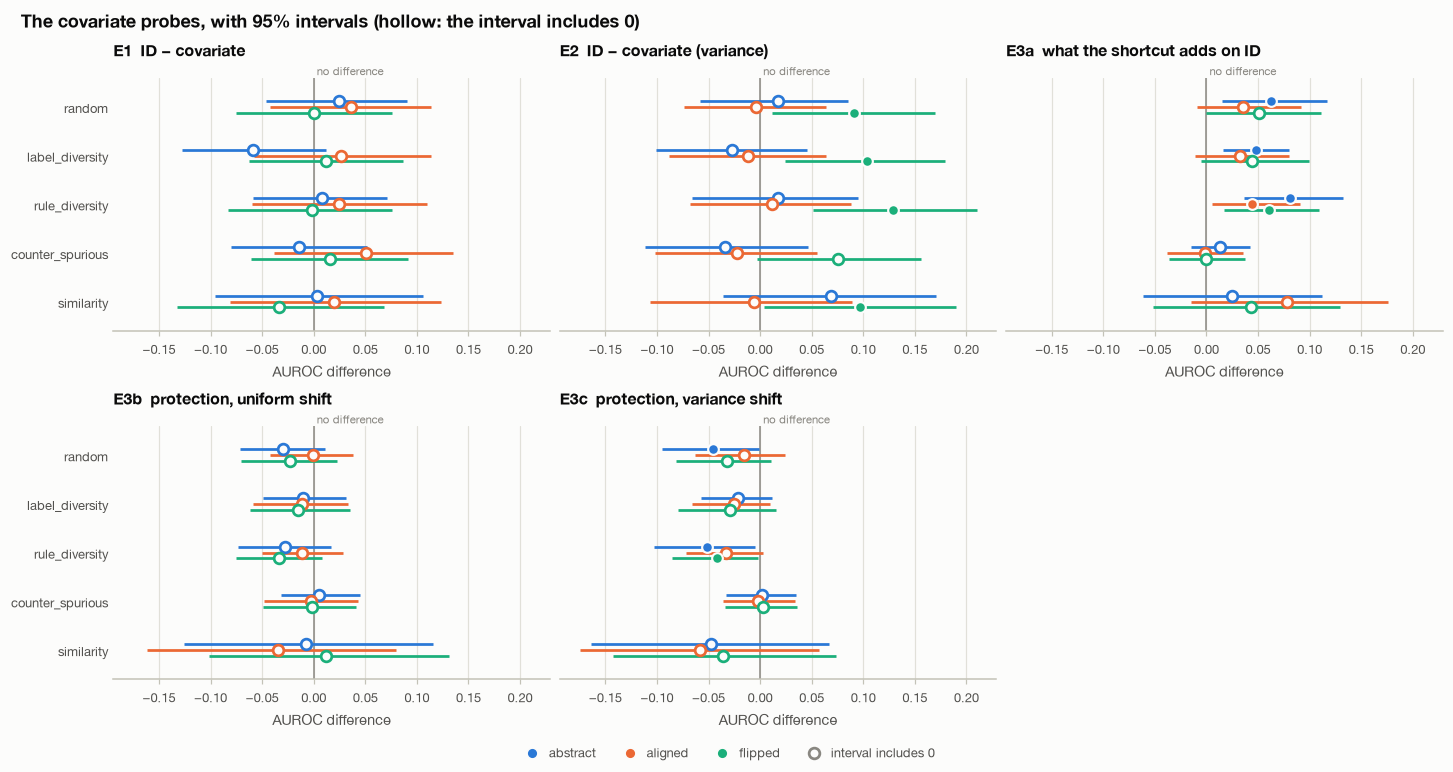

In [25]:
panels = {"E1": "E1  ID − covariate", "E2": "E2  ID − covariate (variance)",
          "E3a": "E3a  what the shortcut adds on ID", "E3b": "E3b  protection, uniform shift",
          "E3c": "E3c  protection, variance shift"}
ex2 = ex.assign(panel=ex["id"].map(panels), excludes_zero=(ex.ci_low > 0) | (ex.ci_high < 0))
fig = plots.facet_dots(ex2, facet="panel", y="strategy", x="estimate", hue="naming", facet_order=list(panels.values()),
                       y_order=[s for s in STRATEGY_ORDER if s in set(ex2.strategy)], hue_order=plots.NAMINGS,
                       lo="ci_low", hi="ci_high", filled="excludes_zero", ref=0, ref_label="no difference",
                       xlabel="AUROC difference", hollow_note=True, ncols=3,
                       title="The covariate probes, with 95% intervals (hollow: the interval includes 0)")
plt.show()

**Reading the chart.** Each panel is one probe, each row a strategy, each colour a naming. Filled dots have intervals that exclude 0.
- **E2:** the variance shift hurts only under flipped names (aqua, +0.08 to +0.13).
- **E3a:** making the shortcut uninformative costs ID AUROC (0.05–0.08), except for counter_spurious, which never taught it.
- **E3b:** without the shortcut, the covariate gap does not grow (about 0). The shortcut is not hiding covariate harm.